In [7]:
from pathlib import Path

from prismadv.data_models import Constraints
from workflow_prismadv.utils.results_analysis import build_confusion_matrices
from workflow_prismadv.utils.results_analysis import collect_results
from workflow_prismadv.utils.results_analysis import format_results_latex

In [8]:
dataset_name_options = ["students", "hr_analytics", "sleep_health", "IPL_win_prediction", "imdb"]
model_order = ["gemini-2.5-flash", "gpt-4.1", "gpt-4o", "gpt-5-mini", "gemini-2.5-pro", "gpt-5"]
unique_subset_cols = [
    "llm_name", "llm_temperature",
    "dataset_name", "subtask_name",
    "processed_data_label", "script_name", "is_clean"
]

In [9]:
def meta_extractor_zero_shot(constraint_file: Path, raw: dict) -> dict:
    parts = constraint_file.stem.split("--")
    llm_name = parts[1] if len(parts) > 1 else "unknown"
    return {
        "llm_name": llm_name,
        "llm_temperature": 0.6,
        "timestamp": constraint_file.stem.split("--")[-1],
    }


def constraints_parser_few_shot(raw: dict):
    return Constraints.from_dict({"constraints": raw["constraints"]})


df_all_unique = collect_results(
    dataset_name_options=dataset_name_options,
    unique_subset_cols=unique_subset_cols,
    constraint_glob="single_shot*.yaml",
    row_meta_extractor=meta_extractor_zero_shot,
    constraints_parser=constraints_parser_few_shot,
    model_order=model_order,  # optional filter
)

In [10]:
confusion_matrices_df = build_confusion_matrices(df_all_unique)

In [11]:
latex_output = format_results_latex(
    confusion_matrex_df=confusion_matrices_df,
    dataset_name_options=dataset_name_options,
    model_order=model_order,
    decimals=1,
    model_label_prefix="zero-shot",
    include_overall=True
)
print(latex_output)

%% === Dataset: students ===
& \texttt{zero-shot [gemini-2.5-flash]} & 78.0 & 34.8 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
& \texttt{zero-shot [gpt-4.1]} & 38.9 & 10.3 & 21 & 110 & 98 & 21 & 50.0\% & 16.0\% & 24.3\% \\
& \texttt{zero-shot [gpt-4o]} & 21.5 & 2.2 & 22 & 109 & 106 & 13 & 62.9\% & 16.8\% & 26.5\% \\
& \texttt{zero-shot [gpt-5-mini]} & 20.7 & 10.8 & 25 & 106 & 113 & 6 & 80.6\% & 19.1\% & 30.9\% \\
& \texttt{zero-shot [gemini-2.5-pro]} & 11.4 & 4.6 & 8 & 123 & 107 & 12 & 40.0\% & 6.1\% & 10.6\% \\
& \texttt{zero-shot [gpt-5]} & 46.9 & 5.7 & 0 & 131 & 119 & 0 & - & 0.0\% & - \\
%% === Dataset: hr_analytics ===
& \texttt{zero-shot [gemini-2.5-flash]} & 80.5 & 30.7 & 0 & 167 & 133 & 0 & - & 0.0\% & - \\
& \texttt{zero-shot [gpt-4.1]} & 25.6 & 5.7 & 58 & 109 & 105 & 28 & 67.4\% & 34.7\% & 45.8\% \\
& \texttt{zero-shot [gpt-4o]} & 24.3 & 1.3 & 17 & 150 & 116 & 17 & 50.0\% & 10.2\% & 16.9\% \\
& \texttt{zero-shot [gpt-5-mini]} & 19.6 & 2.3 & 49 & 118 & 110 & 23 & 68.1\% & 29.3\% & 

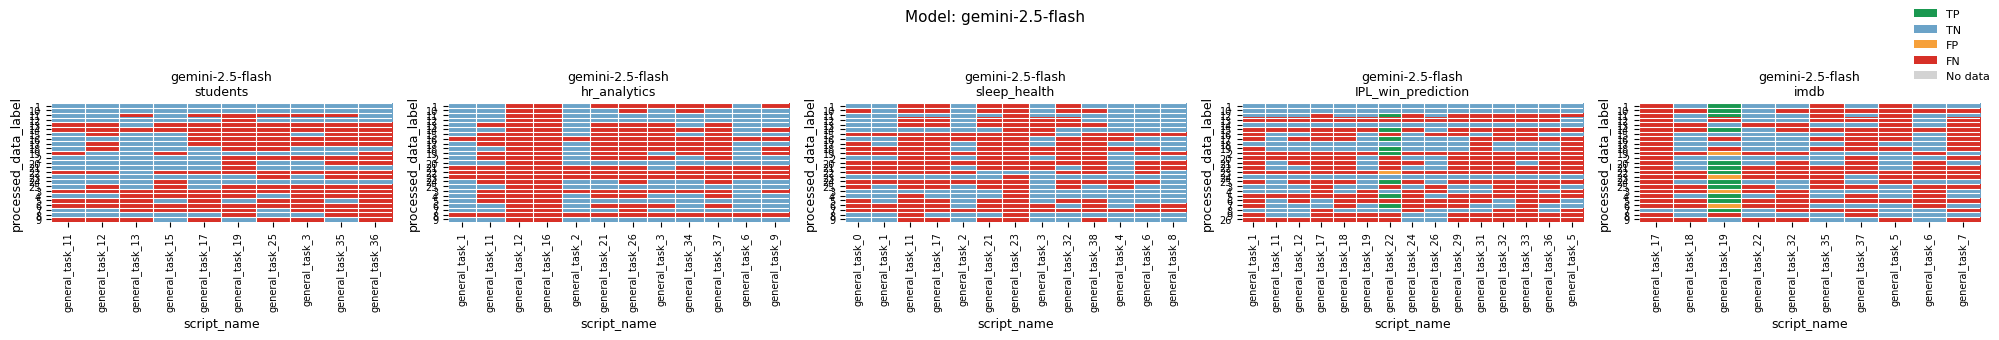

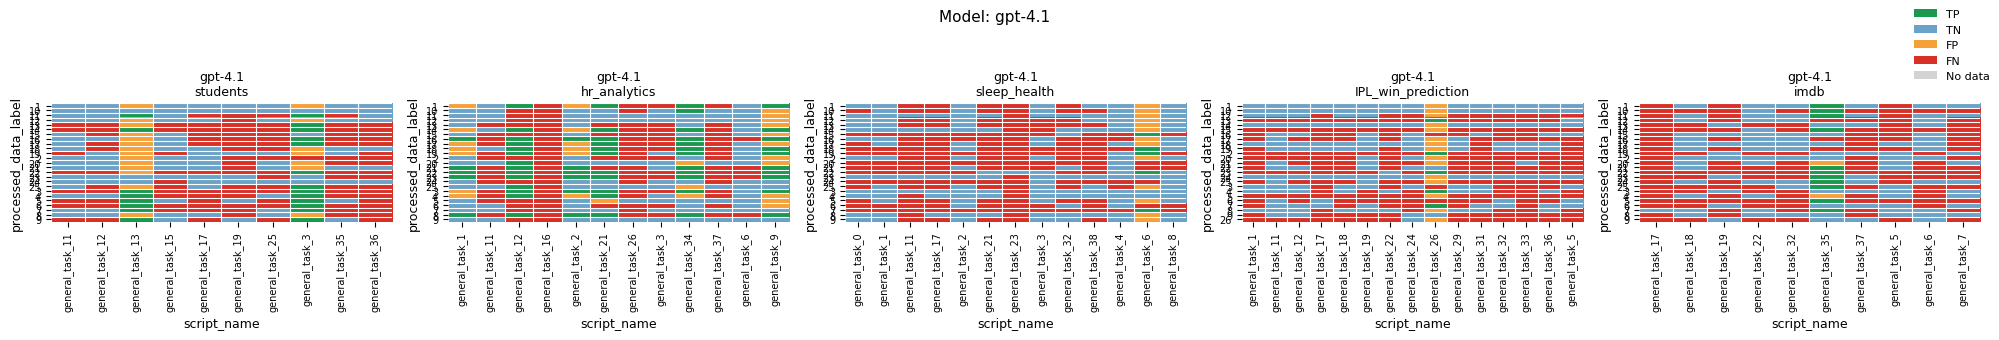

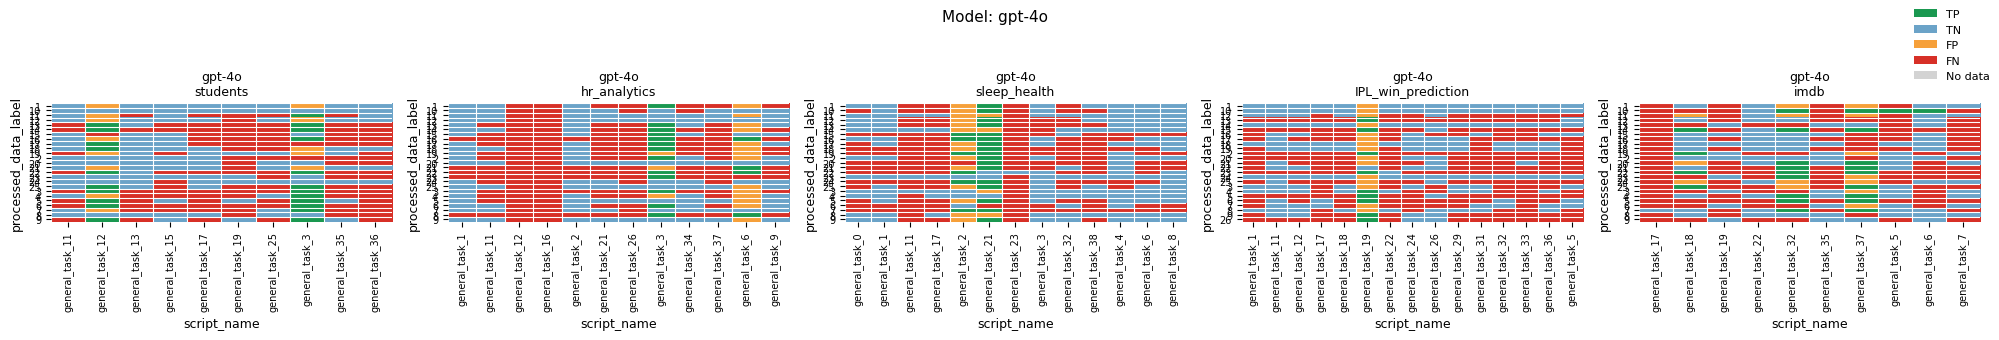

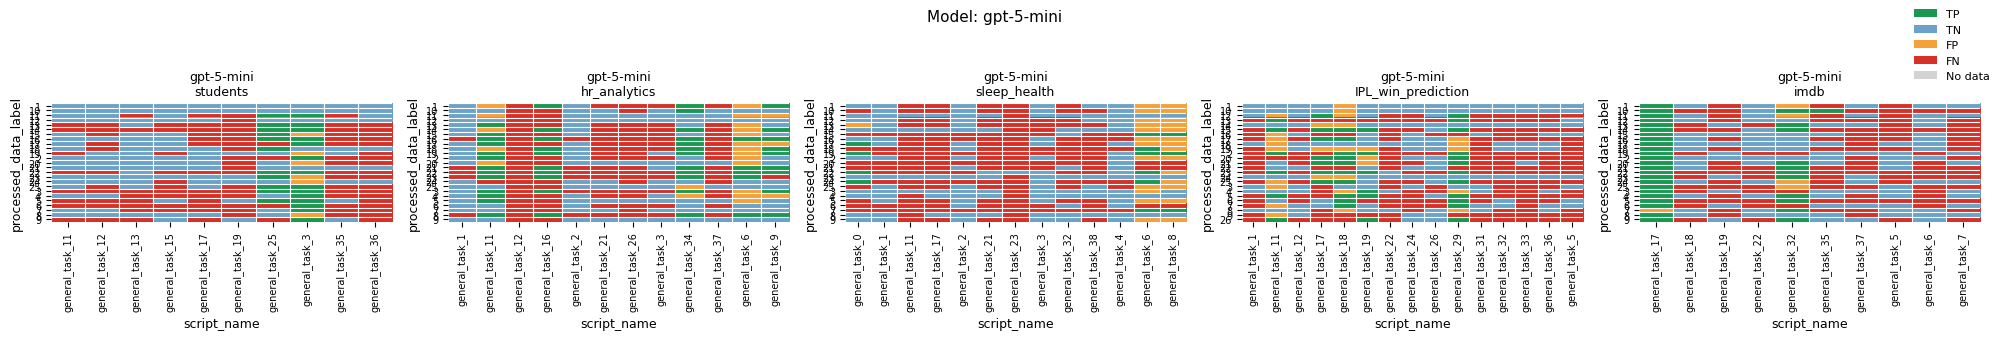

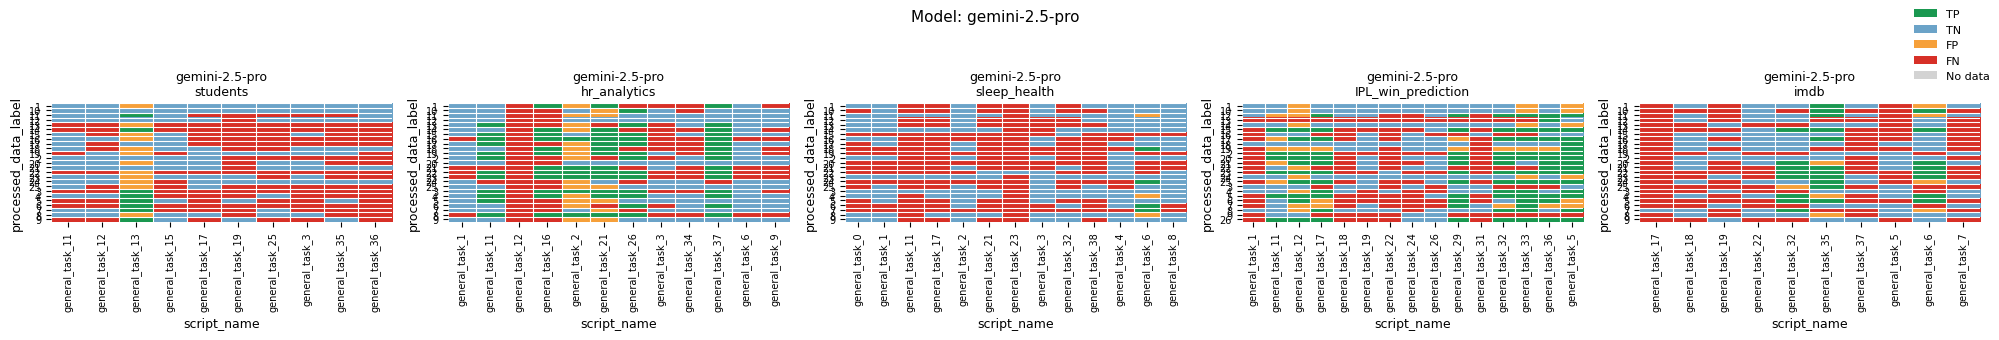

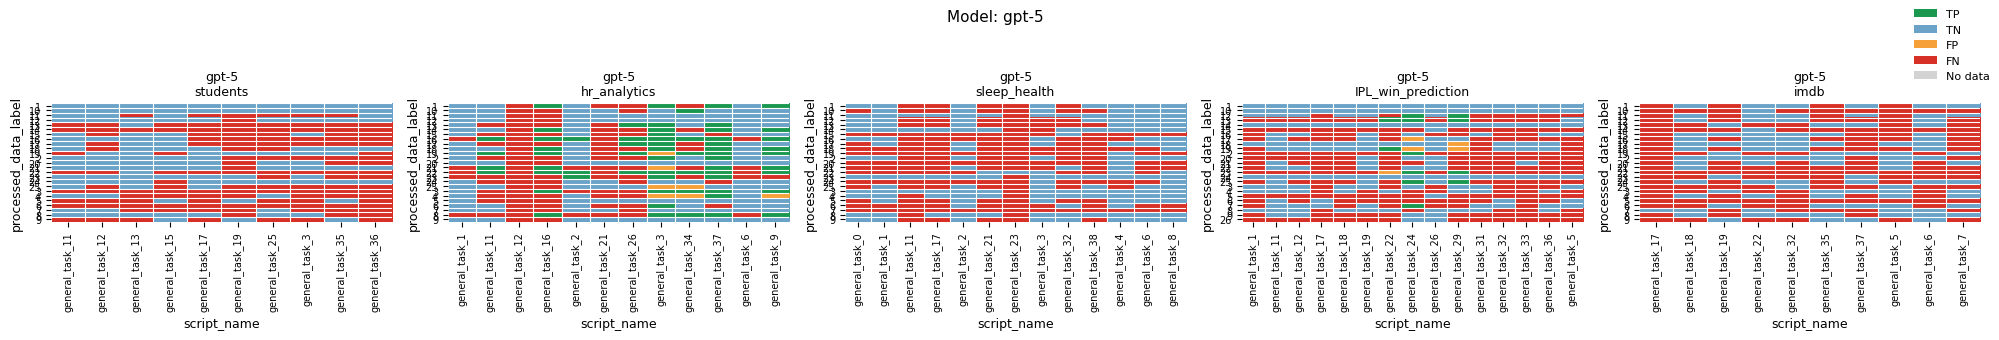

In [12]:
from workflow_prismadv.utils.results_analysis import build_correct_grids, plot_correct_grids

grids = build_correct_grids(df_all_unique, dataset_name_options, threshold=0.5)
plot_correct_grids(grids, model_order=model_order, dataset_name_options=dataset_name_options)